## 1. What this notebook computes

The other notebooks of this chapter derive the field equations for $a_4(x_4)$ and
the source that a given $a_4$ requires. Here we ask whether a field of the theory
can BE that source, exactly, with the extra times deflating exponentially. The
Revision record proves three things about a homogeneous condensate of the commuting
field dirac16complex00 (a solution $\Phi(x_4)$ that depends on the time only):

1. it can be a source of the author's metric only for the linear member
   $a_4 = AHx_4 + a_0$, and then only if 15 numbers built from it, the three-gamma
   bilinears, are zero;
2. in Einstein gravity it must then meet two conditions that tie its mass $m$,
   its self-coupling $\lambda$ and its density $S$ to $A$ and $\Lambda$;
3. condensates with all 15 bilinears zero exist (exact examples).

The record states that it contains no check that combines 3 with 2. This notebook
does that combination, with exact arithmetic (rational and complex-rational
numbers, never rounded) and the author's gamma matrices. It

- rebuilds the spin-connection term $\gamma^\mu\Omega_\mu = 3H\gamma^{(x_8)}$ and
  the condensate equation, and solves it for every starting spinor;
- builds a one-parameter family of condensates with all 15 bilinears zero and a
  density $S$ of either sign;
- computes their complete energy-momentum tensor (all 64 components) in the
  author's metric with an arbitrary $a_4(x_4)$;
- solves the two Einstein conditions and finds three exact solutions of the
  coupled equations, two of them with the extra times deflating as $e^{-Hx_4}$;
- checks all 16 components of the field equation of the condensate and all 64
  components of the Einstein equations, at every time $x_4$ and every value of
  the hidden coordinate;
- states exactly what this shows and what it does not, and draws six plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 12d (An exact solution: a condensate of dirac16complex00 as the source of the
deflating member) is the file `Revision/textbook/notebooks/12d_condensate_solution.ipynb`
of the repository Dirac_claude. It builds, with exact arithmetic and the author's gamma
matrices, homogeneous condensates of the commuting field dirac16complex00 whose 15
three-gamma bilinears vanish, computes their complete energy-momentum tensor in the
author's metric, chooses the mass, the self-coupling and the cosmological constant so
that the Einstein equations hold, and checks every component of the field equation of the
condensate and of the Einstein equations for the exponentially deflating linear member a4
= H x4 (and a4 = sqrt(5) H x4), at every time x4 and every value of the hidden
coordinate. It reproduces the Revision records where they overlap and draws six teaching
plots. The combination of a condensate with the Einstein conditions is a computation of
this notebook; the Revision record states that it does not contain one. It needs a
computer with Windows 11, macOS or Linux, an internet connection for the installation,
the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
and nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other
packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 12d_condensate_solution.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 25 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 12d_condensate_solution.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
12d_condensate_solution.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/12d.captions.json`
- `Revision/textbook/figures/12d_1_condensate_frequency.png`
- `Revision/textbook/figures/12d_2_three_gamma_bilinears.png`
- `Revision/textbook/figures/12d_3_allowed_sources.png`
- `Revision/textbook/figures/12d_4_tensor_equality.png`
- `Revision/textbook/figures/12d_5_solution_in_time.png`
- `Revision/textbook/figures/12d_6_family_in_lambda.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all six figure files exist
    ALL 40 CHECKS PASSED (notebook 12d)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/12d_condensate_solution.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming a file below the folder Revision: the notebook reads the
  Revision records of the repository. Run it inside the folder
  Revision/textbook/notebooks of a complete copy of the repository made with git clone,
  not on a copy of the notebook file alone.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 12d (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 12d (An exact solution: a condensate of dirac16complex00 as the source of the
# deflating member) is the file Revision/textbook/notebooks/12d_condensate_solution.ipynb
# of the repository Dirac_claude. It builds, with exact arithmetic and the author's gamma
# matrices, homogeneous condensates of the commuting field dirac16complex00 whose 15
# three-gamma bilinears vanish, computes their complete energy-momentum tensor in the
# author's metric, chooses the mass, the self-coupling and the cosmological constant so
# that the Einstein equations hold, and checks every component of the field equation of
# the condensate and of the Einstein equations for the exponentially deflating linear
# member a4 = H x4 (and a4 = sqrt(5) H x4), at every time x4 and every value of the
# hidden coordinate. It reproduces the Revision records where they overlap and draws six
# teaching plots. The combination of a condensate with the Einstein conditions is a
# computation of this notebook; the Revision record states that it does not contain one.
# It needs a computer with Windows 11, macOS or Linux, an internet connection for the
# installation, the program Git, and Python 3.12 or newer (the notebooks were built with
# Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
# 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
# 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy
# and matplotlib; the other packages run Jupyter, the program that shows and runs
# notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 12d_condensate_solution.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 25
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 12d_condensate_solution.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 12d_condensate_solution.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/12d.captions.json
# - Revision/textbook/figures/12d_1_condensate_frequency.png
# - Revision/textbook/figures/12d_2_three_gamma_bilinears.png
# - Revision/textbook/figures/12d_3_allowed_sources.png
# - Revision/textbook/figures/12d_4_tensor_equality.png
# - Revision/textbook/figures/12d_5_solution_in_time.png
# - Revision/textbook/figures/12d_6_family_in_lambda.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all six figure files exist
#     ALL 40 CHECKS PASSED (notebook 12d)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/12d_condensate_solution.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming a file below the folder Revision: the notebook reads the
#   Revision records of the repository. Run it inside the folder
#   Revision/textbook/notebooks of a complete copy of the repository made with git clone,
#   not on a copy of the notebook file alone.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "12d"  # this notebook: chapter 12, example d


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 12d complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** $x_1, \dots, x_8$ (the author's names): $x_1, x_2, x_3$ ordinary
  3-space, $x_4$ the time, $x_5, x_6, x_7$ the three extra times (which deflate
  exponentially), $x_8$ the hidden direction with $z = 6Hx_8$ in $(0, \pi/2)$. In the
  code the positions 0 to 7 of a list stand for $x_1$ to $x_8$.
- **Gamma matrices** $\gamma^{(x_1)}, \dots, \gamma^{(x_8)}$: the author's eight real
  16 by 16 matrices with $\gamma^{(a)}\gamma^{(b)} + \gamma^{(b)}\gamma^{(a)} =
  2\eta^{ab}$, $\eta = \mathrm{diag}(+,+,+,-,-,-,-,+)$ (the Clifford relation).
- **Spinor** $\Phi$: a column of 16 complex numbers (here: functions of $x_4$).
  dirac16complex00 is a field of such spinors whose components are ordinary
  (commuting) complex numbers.
- **Adjoint** $\bar\Phi = \Phi^\dagger C$ with $C = \gamma^{(x_8)}\gamma^{(x_1)}
  \gamma^{(x_2)}\gamma^{(x_3)}$; $\Phi^\dagger$ is the row of complex conjugates.
- **Density** $S = \bar\Phi\Phi$, a real number. **Bilinear**: a number
  $\bar\Phi X \Phi$ with a 16 by 16 matrix $X$; a **three-gamma bilinear** has
  $X = \gamma^{(a)}\gamma^{(b)}\gamma^{(c)}$ with three different directions.
- **Mass** $m$, **self-coupling** $\lambda$, **potential** $U(S) = \tfrac\lambda2 S^2$
  with $U'(S) = \lambda S$; **effective mass** $M = m + \lambda S$.
- **Spin connection** $\Omega_\mu$: the 16 by 16 matrices that make the derivative
  of a spinor covariant, $D_\mu\Phi = \partial_\mu\Phi + \Omega_\mu\Phi$.
- **Condensate**: a solution that depends on the time $x_4$ only.
- **Frequency** $w$: in $e^{-iwx_4}$, the number of radians per unit of time.
- **Energy-momentum tensor** $T^\mu{}_\nu$: the energy density
  $\rho = -T^{x_4}{}_{x_4}$, the pressures $p_\mu = T^\mu{}_\mu$ (no sum), and the
  mixed components; **sign convention** $\sigma_T = +1$ of the Revision record.
- **Einstein equations** with cosmological constant $\Lambda$ and coupling
  $\kappa$: $G^\mu{}_\nu + \Lambda\delta^\mu_\nu = \kappa T^\mu{}_\nu$.
- **Linear member** $a_4 = AHx_4 + a_0$: for $A > 0$ the extra times deflate as
  $e^{-AHx_4}$ while 3-space inflates as $e^{AHx_4}$.
- **Witness**: an explicit example that proves that something exists.
- **Units**: $H = 1$ and $\kappa = 1$ in the examples ($\kappa$ and the size of
  $\Phi$ enter the equations only through $\kappa S$).

## 4. The physical and mathematical situation

The coupled equations are, for the field (the Euler-Lagrange equation of the
Revision record, with $\gamma^\mu = e_a{}^\mu\gamma^{(a)}$ the gammas of the curved
metric),

$$\gamma^\mu D_\mu\Phi = (m + U'(S))\,\Phi,$$

and for the metric, in Einstein gravity,

$$G^\mu{}_\nu + \Lambda\delta^\mu_\nu = \kappa T^\mu{}_\nu,\qquad
T^\mu{}_\nu = \sigma_T\big(-K^{(\mu}{}_{\nu)} + \delta^\mu_\nu L\big),$$

$$K^\mu{}_\nu = \tfrac12\big(\bar\Phi\gamma^\mu D_\nu\Phi
- (D_\nu\bar\Phi)\gamma^\mu\Phi\big),\qquad
L = \sum_\mu K^\mu{}_\mu - mS - U(S),$$

where $K^{(\mu}{}_{\nu)}$ is the symmetrised kinetic tensor and $L$ the Lagrangian
on shell (the record's formulas; $\sigma_T = +1$). For the linear member the
Einstein tensor is diagonal with $G^{x_4}{}_{x_4} = (21 + 3A^2)H^2$ and all seven
other diagonal entries $(15 - 3A^2)H^2$.

**Status.** Every check below is an exact identity verified by computer algebra
(PROVED for the stated numbers). ASSUMED: Einstein gravity, the sign convention
$\sigma_T = +1$, the classical commuting field dirac16complex00 (not the quantised
dirac16complex), and the values of $\Lambda$, $m$, $\lambda$ chosen below. The
combination of a condensate with the Einstein conditions is new in this notebook;
it is not a Revision record.

## 5. The Revision records this notebook reproduces

The next cell defines the helpers that read the Revision records: `read_json`
reads a JSON file of the repository, `record_verdict` finds a check by its name in
a report, and `reproduces` is a check that passes only when this notebook's own
result holds AND the record lists the named check with the verdict PASS (it
collects its two printed lines in a text buffer and prints them with one call, so
that they always stay together in the output). It then
prints the sentence of the record's document that this notebook answers.

In [2]:
import contextlib  # redirect_stdout: send printed lines into a buffer
import io  # StringIO: a text buffer in memory

GAMMAS = "Revision/algebra/gammas.json"  # the author's gamma matrices
EQUATIONS = "Revision/field_equations_a4/a4-equations.json"  # the a4 equations
PY = "Revision/field_equations_a4/reports/python-a4-report.json"  # sympy record
WL = "Revision/field_equations_a4/reports/wolfram-a4-report.json"  # Wolfram record
EMT = "Revision/lead_checks/reports/emt-divergence-and-spin-connection.json"
DOC = "Revision/docs/DIRAC16COMPLEX00_FIELD_THEORY.md"  # the record's document


def read_json(relative):
    """Read a JSON file of the repository (a Revision record)."""
    return json.loads(repository_file(relative).read_text(encoding="utf-8"))


def record_verdict(report_file, name):
    """The verdict of the check name in a report ("PASS"), None if absent."""
    for entry in read_json(report_file)["checks"]:
        if entry["name"] == name:
            return entry["verdict"]
    return None


def reproduces(condition, name, report_file, record_name):
    """A check that also requires the record check record_name to be PASS.  Its
    printed lines (PASS and reproduces) are collected in a text buffer and printed
    by one print call, so that they always stay together in the cell's output."""
    found = record_verdict(report_file, record_name) == "PASS"
    lines = io.StringIO()  # a text buffer
    with contextlib.redirect_stdout(lines):  # print() now writes into the buffer
        check(condition and found, name, record=f"{report_file}, check {record_name}")
    print(lines.getvalue(), end="")  # all lines at once


OPEN_SENTENCE = ("This record contains no check that combines a witness with the "
                 "Einstein conditions")
document = repository_file(DOC).read_text(encoding="utf-8")
say(f"{DOC} says: \"{OPEN_SENTENCE}.\"")
check(OPEN_SENTENCE in document, "the record leaves this combination open")

Revision/docs/DIRAC16COMPLEX00_FIELD_THEORY.md says: "This record contains no check that
    combines a witness with the Einstein conditions."
PASS the record leaves this combination open


## 6. The author's gamma matrices and the matrix $C$

The next cell reads the eight gamma matrices from the Revision record
`gammas.json` (each entry an integer or a fraction written as text, which
`sp.Rational` turns into an exact number), checks the Clifford relation for all 64
pairs, builds $C = \gamma^{(x_8)}\gamma^{(x_1)}\gamma^{(x_2)}\gamma^{(x_3)}$,
compares it with the $C$ stored in the record, and checks the three properties the
adjoint needs: $C$ is real and symmetric, $C^2 = 1$, and every $C\gamma^{(a)}$ is
antisymmetric.

In [3]:
import itertools  # loops over all combinations of indices

import numpy as np  # floating-point arrays, used only for the plots
import sympy as sp  # exact algebra

NAMES = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]  # positions 0..7
ETA = [1, 1, 1, -1, -1, -1, -1, 1]  # the frame metric eta, x1..x8
I16, Z16 = sp.eye(16), sp.zeros(16, 16)  # the 16 by 16 unit and zero matrices
fixture = read_json(GAMMAS)
gamma = [sp.Matrix([[sp.Rational(x) for x in row] for row in matrix])
         for matrix in fixture["gamma"]]  # gamma[a] = gamma^(x_(a+1))
clifford = all(gamma[a] * gamma[b] + gamma[b] * gamma[a]
               == 2 * ETA[a] * (1 if a == b else 0) * I16
               for a in range(8) for b in range(8))
reproduces(clifford, "the author's gammas satisfy the Clifford relation",
           PY, "authorT16_clifford")
C = gamma[7] * gamma[0] * gamma[1] * gamma[2]  # C = g^(x8) g^(x1) g^(x2) g^(x3)
stored_C = sp.Matrix([[sp.Rational(x) for x in row] for row in fixture["C"]])
properties = (C == stored_C and C == C.T and C * C == I16
              and all((C * g).T == -(C * g) for g in gamma))
reproduces(properties, "C is the record's C, real symmetric, C^2 = 1, C gamma "
           "antisymmetric", PY, "authorT16_C_properties")

PASS the author's gammas satisfy the Clifford relation
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    authorT16_clifford
PASS C is the record's C, real symmetric, C^2 = 1, C gamma antisymmetric
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    authorT16_C_properties


## 7. The spin connection and the term $3H\gamma^{(x_8)}$

The vielbein of the author's diagonal metric is diagonal: $e^a{}_\mu = E_a
\delta^a_\mu$ with $E_a = \sqrt{|g_{aa}|}$, that is $E = (e^{a_4}s, e^{a_4}s,
e^{a_4}s, 1, e^{-a_4}s, e^{-a_4}s, e^{-a_4}s, \cot z)$ with $s = \sin^{1/6} z$.
The canonical spin connection is
$\omega_\mu{}^a{}_b = e^a{}_\nu(\partial_\mu e_b{}^\nu + \Gamma^\nu{}_{\mu\lambda}
e_b{}^\lambda)$ with the inverse vielbein $e_b{}^\nu = \delta_b^\nu/E_b$. For
$a = b$ the two terms cancel ($E_a\partial_\mu(1/E_a) = -\partial_\mu\ln E_a$ and
$\Gamma^a{}_{\mu a} = \partial_\mu\ln E_a$); for $a \ne b$ only the second survives:

$$\omega_{\mu\,ab} = \eta_{aa}\,\omega_\mu{}^a{}_b
= \eta_{aa}\,\frac{E_a}{E_b}\,\Gamma^a{}_{\mu b}\qquad(a \ne b),$$

and $\Omega_\mu = \tfrac12\sum_{a,b}\omega_{\mu\,ab}S^{ab}$ with
$S^{ab} = \tfrac14[\gamma^{(a)}, \gamma^{(b)}]$. The next cell computes the
Christoffel symbols of the diagonal metric (with $\partial/\partial x_8 =
6H\,\partial/\partial z$), the connection and the eight matrices $\Omega_\mu$ for an
arbitrary function $a_4(x_4)$, writing every function of $z$ through
$\cot z$ (the helper `clean`, as in Notebook 12a).

In [4]:
H = sp.symbols("H", positive=True)  # the constant H of the metric
z = sp.symbols("z", positive=True)  # z = 6 H x8 in (0, pi/2)
x4 = sp.symbols("x4", real=True)  # the time
a4 = sp.Function("a4")(x4)  # an arbitrary function a4(x4)
cz = sp.symbols("cz", positive=True)  # cot z > 0 on the patch
ad1, ad2 = sp.symbols("ad1 ad2", real=True)  # a4' and a4''
s6 = sp.sin(z) ** sp.Rational(1, 6)  # the warp sin(z)^(1/6) of a length
E = [sp.exp(a4) * s6] * 3 + [sp.Integer(1)] + [sp.exp(-a4) * s6] * 3 + [sp.cot(z)]
g = [ETA[a] * E[a] ** 2 for a in range(8)]  # g_aa = eta_aa E_a^2
TRIG = {sp.sin(z): 1 / sp.sqrt(1 + cz ** 2), sp.cos(z): cz / sp.sqrt(1 + cz ** 2),
        sp.tan(z): 1 / cz, sp.cot(z): cz}  # every function of z through cot z


def clean(expr):
    """expr with a4', a4'' as ad1, ad2, functions of z through cz, simplified."""
    expr = expr.subs(sp.Derivative(a4, (x4, 2)), ad2).subs(sp.Derivative(a4, x4), ad1)
    expr = sp.expand_trig(expr).subs(TRIG)
    return sp.expand(sp.cancel(sp.powsimp(sp.expand(expr), force=True)))


def d(expr, mu):
    """The partial derivative with respect to the coordinate at position mu."""
    if mu == 3:
        return sp.diff(expr, x4)
    if mu == 7:
        return 6 * H * sp.diff(expr, z)  # d/dx8 = (dz/dx8) d/dz = 6 H d/dz
    return sp.Integer(0)  # nothing depends on x1, x2, x3, x5, x6, x7


Gamma = [[[sp.Integer(0)] * 8 for _ in range(8)] for _ in range(8)]
for a, b, c in itertools.product(range(8), repeat=3):  # diagonal-metric formula
    value = 0
    if a == c:
        value += d(g[a], b)
    if a == b:
        value += d(g[a], c)
    if b == c:
        value -= d(g[b], a)
    Gamma[a][b][c] = value / (2 * g[a])
S_ab = [[(gamma[a] * gamma[b] - gamma[b] * gamma[a]) / 4 for b in range(8)]
        for a in range(8)]
omega = [[[clean(ETA[a] * E[a] * Gamma[a][mu][b] / E[b]) if a != b else 0
           for b in range(8)] for a in range(8)] for mu in range(8)]
antisymmetric = all(sp.expand(omega[mu][a][b] + omega[mu][b][a]) == 0
                    for mu in range(8) for a in range(8) for b in range(8))
check(antisymmetric, "omega_mu ab = -omega_mu ba (canonical spin connection)")
Omega = [sum((omega[mu][a][b] * S_ab[a][b] / 2 for a in range(8) for b in range(8)
              if omega[mu][a][b] != 0), Z16) for mu in range(8)]
for mu in range(8):
    terms = sum(1 for a in range(8) for b in range(8) if omega[mu][a][b] != 0)
    say(f"Omega_{NAMES[mu]}: {terms} nonzero entries omega_mu ab")

PASS omega_mu ab = -omega_mu ba (canonical spin connection)
Omega_x1: 4 nonzero entries omega_mu ab
Omega_x2: 4 nonzero entries omega_mu ab
Omega_x3: 4 nonzero entries omega_mu ab
Omega_x4: 0 nonzero entries omega_mu ab
Omega_x5: 4 nonzero entries omega_mu ab
Omega_x6: 4 nonzero entries omega_mu ab
Omega_x7: 4 nonzero entries omega_mu ab
Omega_x8: 0 nonzero entries omega_mu ab


The next cell forms the curved-space gammas $\gamma^\mu = \gamma^{(\mu)}/E_\mu$
(no sum) and checks three facts that the Revision record proved with the author's
gammas: $\Omega_{x_4} = \Omega_{x_8} = 0$; $\gamma^\mu\Omega_\mu +
\Omega_\mu\gamma^\mu = 0$ for each $\mu$ separately; and the sum
$\sum_\mu\gamma^\mu\Omega_\mu = 3H\gamma^{(x_8)}$, which contains neither $a_4$
nor $z$: the time-direction terms of the three inflating 3-space directions and
of the three deflating extra times cancel.

In [5]:
gamma_curved = [gamma[mu] / E[mu] for mu in range(8)]  # gamma^mu = gamma^(mu)/E_mu
reproduces(Omega[3] == Z16 and Omega[7] == Z16, "Omega_x4 = Omega_x8 = 0",
           PY, "authorT16_Omega_x4_x8_zero")
anticommute = all((gamma_curved[mu] * Omega[mu] + Omega[mu] * gamma_curved[mu])
                  .applyfunc(clean) == Z16 for mu in range(8))
reproduces(anticommute, "{gamma^mu, Omega_mu} = 0 for each mu (no sum)",
           PY, "authorT16_anticommutator_no_sum")
gravity_term = sum((gamma_curved[mu] * Omega[mu] for mu in range(8)), Z16)
gravity_term = gravity_term.applyfunc(clean)
reproduces(gravity_term == 3 * H * gamma[7], "gamma^mu Omega_mu = 3 H gamma^(x8)",
           PY, "authorT16_gravity_term")
reproduces(gravity_term == 3 * H * gamma[7], "the same, the lead's independent check",
           EMT, "gamma_Omega_equals_3H_gamma8")

PASS Omega_x4 = Omega_x8 = 0
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    authorT16_Omega_x4_x8_zero
PASS {gamma^mu, Omega_mu} = 0 for each mu (no sum)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    authorT16_anticommutator_no_sum
PASS gamma^mu Omega_mu = 3 H gamma^(x8)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    authorT16_gravity_term
PASS the same, the lead's independent check
     reproduces Revision/lead_checks/reports/emt-divergence-and-spin-connection.json,
    check gamma_Omega_equals_3H_gamma8


## 8. The condensate equation and its solution for every starting spinor

For $\Phi = \Phi(x_4)$ only the $x_4$ derivative survives, and $\gamma^{x_4} =
\gamma^{(x_4)}$ (because $E_4 = 1$). With the term of section 7 the field equation
becomes $\gamma^{(x_4)}\Phi' + 3H\gamma^{(x_8)}\Phi = M\Phi$, $M = m + U'(S)$.
Multiplying by $\gamma^{(x_4)}$ and using $(\gamma^{(x_4)})^2 = -1$:

$$\Phi' = \mathcal{A}\,\Phi,\qquad \mathcal{A} = -\gamma^{(x_4)}\big(M -
3H\gamma^{(x_8)}\big).$$

The matrix $\mathcal{A}$ contains neither $a_4$ nor $z$: the condensate does not
feel the deflation at all. Squaring, with $(\gamma^{(x_4)})^2 = -1$,
$(\gamma^{(x_8)})^2 = 1$ and $\gamma^{(x_4)}\gamma^{(x_8)} =
-\gamma^{(x_8)}\gamma^{(x_4)}$, the mixed terms cancel and

$$\mathcal{A}^2 = -(M^2 - 9H^2)\cdot 1 .$$

So, for $M^2 > 9H^2$ and $w = \sqrt{M^2 - 9H^2}$, every solution is
$\Phi(x_4) = \cos(wx_4)\,\Phi(0) + \tfrac{\sin(wx_4)}{w}\,\mathcal{A}\Phi(0)$
(differentiate twice: $\Phi'' = -w^2\Phi$, and $\Phi'(0) = \mathcal{A}\Phi(0)$).
The next cell checks the reduction, the square, and $C\mathcal{A} +
\mathcal{A}^TC = 0$, which makes $S$ constant: $S' = \Phi^\dagger(\mathcal{A}^T C
+ C\mathcal{A})\Phi = 0$ (the matrices are real, $M$ is real).

In [6]:
MM = sp.symbols("M", real=True)  # the effective mass M = m + lambda S


def condensate_matrix(M_value, H_value):
    """The matrix A of Phi' = A Phi for given M and H."""
    return -gamma[3] * (M_value * I16 - 3 * H_value * gamma[7])


A_sym = condensate_matrix(MM, H)
reduced = (gamma[3] * A_sym + gravity_term - MM * I16).applyfunc(sp.expand)
reproduces(reduced == Z16 and not A_sym.has(z),
           "gamma^(x4) A + 3 H gamma^(x8) = M: the equation is Phi' = A Phi",
           WL, "condensate_equation_x8_consistent")
check((A_sym * A_sym + (MM ** 2 - 9 * H ** 2) * I16).applyfunc(sp.expand) == Z16,
      "A^2 = -(M^2 - 9 H^2): every condensate oscillates with w = sqrt(M^2 - 9 H^2)")
reproduces((C * A_sym + A_sym.T * C).applyfunc(sp.expand) == Z16,
           "C A + A^T C = 0: S is constant along x4", PY,
           "authorT16_condensate_S_constant")

PASS gamma^(x4) A + 3 H gamma^(x8) = M: the equation is Phi' = A Phi
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    condensate_equation_x8_consistent
PASS A^2 = -(M^2 - 9 H^2): every condensate oscillates with w = sqrt(M^2 - 9 H^2)
PASS C A + A^T C = 0: S is constant along x4
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    authorT16_condensate_S_constant


The next cell draws the frequency $w = \sqrt{M^2 - 9H^2}$ against $M/H$ and, as
dots, the imaginary parts of the 16 eigenvalues of $\mathcal{A}$ computed
numerically at a few values of $M$ (they are $\pm iw$, each eight times). For
$|M| < 3H$ the eigenvalues are real, $\pm\sqrt{9H^2 - M^2}$: the condensate grows
or decays exponentially instead of oscillating (shaded band). The examples of this
notebook use $M = \pm 5H$, where $w = 4H$.

largest deviation of a numerical eigenvalue from +-i w: 1e-14
PASS the 16 eigenvalues of A are +-i w (numerically, six masses)


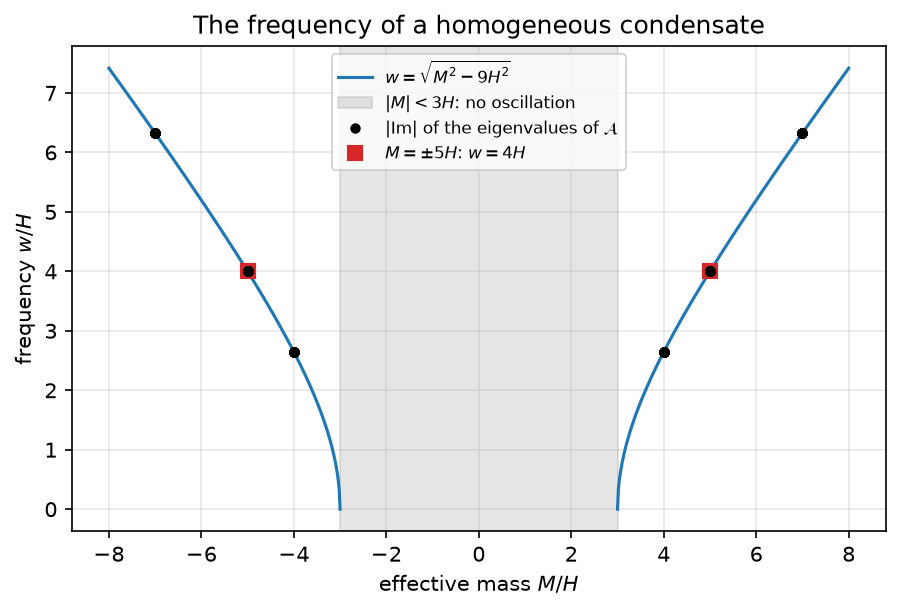

Figure 12d.1 saved as Revision/textbook/figures/12d_1_condensate_frequency.png


In [7]:
m_axis = np.linspace(-8.0, 8.0, 801)  # M/H
fig, ax = plt.subplots()
ax.plot(m_axis[m_axis <= -3.0], np.sqrt(m_axis[m_axis <= -3.0] ** 2 - 9.0),
        color="tab:blue", label="$w = \\sqrt{M^2 - 9H^2}$")
ax.plot(m_axis[m_axis >= 3.0], np.sqrt(m_axis[m_axis >= 3.0] ** 2 - 9.0),
        color="tab:blue")
ax.axvspan(-3.0, 3.0, color="grey", alpha=0.2, label="$|M| < 3H$: no oscillation")
worst = 0.0  # the largest deviation of a numerical eigenvalue from +-i w
for M_value in (-7.0, -5.0, -4.0, 4.0, 5.0, 7.0):
    matrix = np.array(condensate_matrix(M_value, 1).tolist(), dtype=float)
    eigenvalues = np.linalg.eigvals(matrix)
    w_value = np.sqrt(M_value ** 2 - 9.0)
    worst = max(worst, np.max(np.abs(np.abs(eigenvalues.imag) - w_value)),
                np.max(np.abs(eigenvalues.real)))
    ax.plot([M_value] * 16, np.abs(eigenvalues.imag), "o", color="black",
            markersize=4, zorder=3)  # zorder 3: drawn on top of the red squares
ax.plot([], [], "o", color="black", markersize=4,
        label="$|\\mathrm{Im}|$ of the eigenvalues of $\\mathcal{A}$")
ax.plot([-5, 5], [4, 4], "s", color="tab:red", markersize=7,
        label="$M = \\pm5H$: $w = 4H$")
ax.set_xlabel("effective mass $M/H$")
ax.set_ylabel("frequency $w/H$")
ax.set_title("The frequency of a homogeneous condensate")
ax.legend(fontsize=8, loc="upper center")
say(f"largest deviation of a numerical eigenvalue from +-i w: {worst:.0e}")
check(worst < 1e-9, "the 16 eigenvalues of A are +-i w (numerically, six masses)")
save_figure(fig, "condensate_frequency",
            "The frequency $w$ of a homogeneous condensate of dirac16complex00 in "
            "the author's metric as a function of its effective mass $M = m + "
            "\\lambda S$, both in units of $H$: the curve $w = \\sqrt{M^2 - 9H^2}$ "
            "from $\\mathcal{A}^2 = -(M^2 - 9H^2)$, and as black dots the absolute "
            "imaginary parts of the 16 eigenvalues of the 16 by 16 matrix "
            "$\\mathcal{A}$, computed numerically at six masses (each dot is eight "
            "eigenvalues). In the grey band $|M| < 3H$ the eigenvalues are real and "
            "the condensate grows or decays instead of oscillating. The red squares "
            "mark $M = \\pm 5H$, $w = 4H$, the masses used in this notebook. The "
            "hidden-direction term $3H\\gamma^{(x_8)}$ of the field equation shifts "
            "the threshold from $0$ to $3H$.")

## 9. Condensates whose 15 three-gamma bilinears vanish

The Revision record shows that the off-diagonal parts of the kinetic tensor of a
condensate are multiples of 15 three-gamma bilinears
$B_{abc} = \bar\Phi\gamma^{(a)}\gamma^{(b)}\gamma^{(c)}\Phi$: the six with
$\{a, b, c\} = \{i, x_4, x_8\}$ ($i$ a 3-space direction or an extra time) and the
nine with $\{i, j, x_4\}$ ($i$ in 3-space, $j$ an extra time). The off-diagonal
Einstein equations $0 = \kappa T^\mu{}_\nu$ need all 15 to vanish. The record's
recipe for such a condensate, at $M = -5$, $H = 1$, $w = 4$: take the spinor $v_1$
with $\mathcal{A}v_1 = -iwv_1$ and $\gamma^{(x_1)}\gamma^{(x_5)} =
\gamma^{(x_2)}\gamma^{(x_6)} = \gamma^{(x_3)}\gamma^{(x_7)} = -1$ on it, the spinor
$v_2$ with the same frequency and the value $+1$, and $c = \overline{v_1^\dagger C
v_2}$ (the bar is the complex conjugate). Each is found as the null space (the
solutions of a set of linear equations) of a stacked matrix. We extend the recipe
to the family

$$\Phi_0(t) = v_1 + t\,c\,v_2\qquad(t \text{ any real number}),$$

and the condensate is $\Phi(x_4) = e^{-iwx_4}\Phi_0(t)$. The next cell builds
$v_1$, $v_2$ and $c$, checks that each null space is one-dimensional, that
$\Phi_0(t)$ has the frequency $w$, and that the 15 bilinears vanish for EVERY real
$t$ (sympy keeps $t$ as a symbol).

In [8]:
t = sp.symbols("t", real=True)  # the free real parameter of the family
TRIPLES = list(itertools.combinations(range(8), 3))  # all 56 sets {a, b, c}
NEEDED = sorted({tuple(sorted((i, 3, 7))) for i in (0, 1, 2, 4, 5, 6)}
                | {tuple(sorted((i, j, 3))) for i in (0, 1, 2) for j in (4, 5, 6)})


def witness_parts(M_value, H_value):
    """v1, v2, c and the frequency w of the record's recipe."""
    w_value = sp.sqrt(M_value ** 2 - 9 * H_value ** 2)
    A_value = condensate_matrix(M_value, H_value)
    spaces = []
    for sign in (-1, 1):  # the eigenvalue of g^(x1)g^(x5) = g^(x2)g^(x6) = ...
        stack = sp.Matrix.vstack(A_value + sp.I * w_value * I16,
                                 gamma[0] * gamma[4] - sign * I16,
                                 gamma[1] * gamma[5] - sign * I16,
                                 gamma[2] * gamma[6] - sign * I16)
        spaces.append(stack.nullspace())  # all solutions of stack * v = 0
    v1, v2 = spaces[0][0], spaces[1][0]
    c = sp.conjugate(sp.expand((v1.H * C * v2)[0]))  # c = conj(v1^dagger C v2)
    return spaces, v1, v2, c, w_value, A_value


def bilinear(phi, matrix):
    """The bilinear phibar matrix phi = phi^dagger C matrix phi."""
    return sp.expand((phi.H * C * matrix * phi)[0])


def three_gamma(triple):
    a, b, c = triple
    return gamma[a] * gamma[b] * gamma[c]


spaces, v1, v2, c, w, A_witness = witness_parts(-5, 1)
phi_t = (v1 + t * c * v2).applyfunc(sp.expand)  # the family Phi_0(t)
check([len(space) for space in spaces] == [1, 1],
      "the two null spaces are one-dimensional (v1 and v2 are unique)")
report("frequency w at M = -5 H", w, "H")
check((A_witness * phi_t + sp.I * w * phi_t).applyfunc(sp.expand)
      == sp.zeros(16, 1), "A Phi_0(t) = -i w Phi_0(t) for every t")
needed_values = [bilinear(phi_t, three_gamma(triple)) for triple in NEEDED]
check(len(NEEDED) == 15 and all(value == 0 for value in needed_values),
      "the 15 three-gamma bilinears vanish for every real t")

PASS the two null spaces are one-dimensional (v1 and v2 are unique)
RESULT frequency w at M = -5 H = 4 H
PASS A Phi_0(t) = -i w Phi_0(t) for every t
PASS the 15 three-gamma bilinears vanish for every real t


**The density of the family.** $S(t) = \Phi_0^\dagger C\Phi_0$ has four parts:
$v_1^\dagger Cv_1$, $t^2|c|^2v_2^\dagger Cv_2$ and the two cross terms
$t\,c\,v_1^\dagger Cv_2 + t\,\bar c\,v_2^\dagger Cv_1 = 2t\,|v_1^\dagger Cv_2|^2$
(because $\bar c = v_1^\dagger Cv_2$ and $v_2^\dagger Cv_1$ is its complex
conjugate, $C$ being real symmetric). The next cell finds the first two zero, so
$S(t) = 2t\,|v_1^\dagger Cv_2|^2$: the family contains condensates of every real
density, positive for $t > 0$ and negative for $t < 0$. It also repeats the
construction at $M = +5$, where the Revision record ran it with the author's
gammas, and checks the record's statement there ($t = 1$: the 15 bilinears vanish,
$S$ is real and not zero).

In [9]:
S_t = bilinear(phi_t, I16)  # S(t) = Phi_0(t)^dagger C Phi_0(t)
cross = sp.expand((v1.H * C * v2)[0])  # v1^dagger C v2
report("v1^dagger C v2", cross)
report("S(t)", S_t)
check(bilinear(v1, I16) == 0 and bilinear(v2, I16) == 0
      and sp.expand(S_t - 2 * t * cross * sp.conjugate(cross)) == 0,
      "S(t) = 2 t |v1^dagger C v2|^2: every real density occurs")
_, u1, u2, c_plus, w_plus, A_plus = witness_parts(5, 1)  # the record's M = +5
phi_plus = (u1 + c_plus * u2).applyfunc(sp.expand)  # t = 1
S_plus = bilinear(phi_plus, I16)
ok_plus = ((A_plus * phi_plus + sp.I * w_plus * phi_plus).applyfunc(sp.expand)
           == sp.zeros(16, 1)
           and all(bilinear(phi_plus, three_gamma(tr)) == 0 for tr in NEEDED)
           and S_plus != 0 and sp.im(S_plus) == 0)
reproduces(ok_plus, "M = +5, H = 1: a witness with S real, not 0, 15 bilinears 0",
           PY, "authorT16_condensate_witness")

RESULT v1^dagger C v2 = -128/25 - 96*I/25
RESULT S(t) = 2048*t/25
PASS S(t) = 2 t |v1^dagger C v2|^2: every real density occurs
PASS M = +5, H = 1: a witness with S real, not 0, 15 bilinears 0
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    authorT16_condensate_witness


The next cell computes all 56 three-gamma bilinears of $\Phi_0(1)$ (at
$M = -5$), checks that each is a real number, and draws them: the 15 that the
field equations need to vanish in red (all zero), the others in blue. Most of the
others vanish as well; the eight that do not are built from three directions
among $x_1, x_2, x_3, x_5, x_6, x_7$ only, and no field equation asks them to
vanish.

PASS all 56 three-gamma bilinears of Phi_0(1) are real numbers
nonzero bilinears: 123, 127, 136, 167, 235, 257, 356, 567
PASS every nonzero one avoids x4 and x8


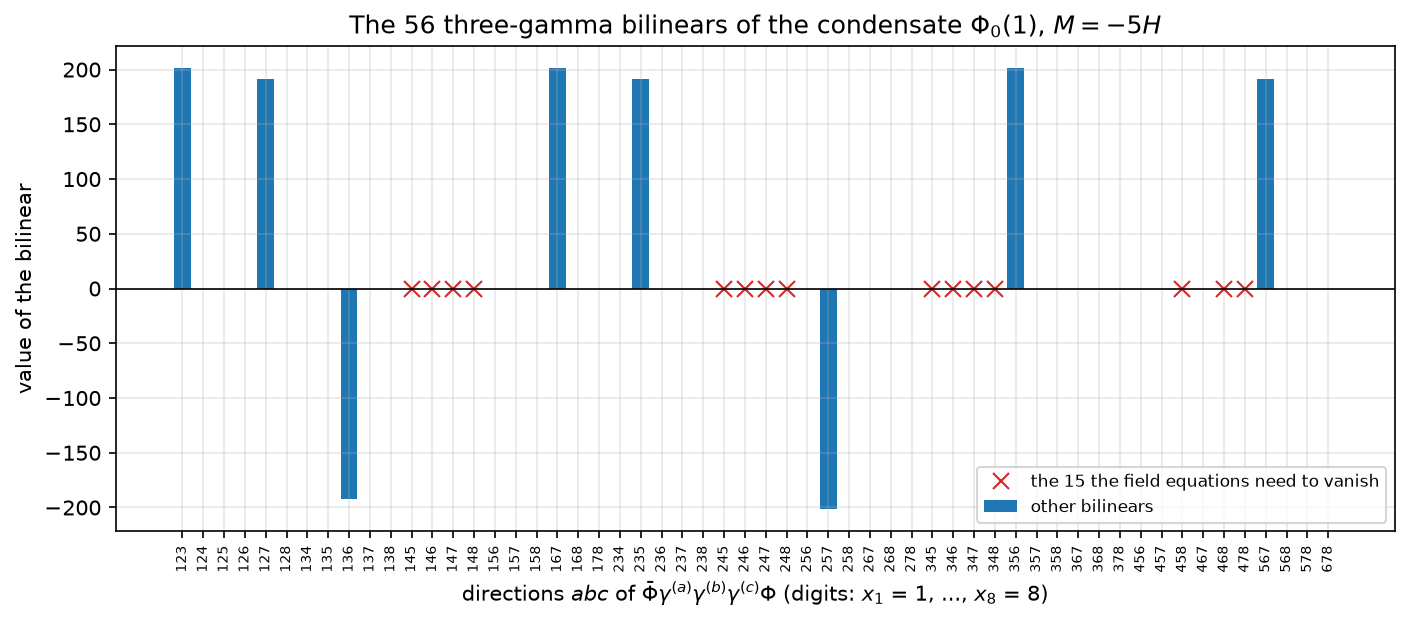

Figure 12d.2 saved as Revision/textbook/figures/12d_2_three_gamma_bilinears.png


In [10]:
phi_one = phi_t.subs(t, 1)  # Phi_0(1)
all_values = [bilinear(phi_one, three_gamma(triple)) for triple in TRIPLES]
check(all(sp.im(value) == 0 for value in all_values),
      "all 56 three-gamma bilinears of Phi_0(1) are real numbers")
nonzero = [triple for triple, value in zip(TRIPLES, all_values) if value != 0]
say("nonzero bilinears: " + ", ".join(
    "".join(NAMES[i][1] for i in triple) for triple in nonzero))
check(all(3 not in triple and 7 not in triple for triple in nonzero),
      "every nonzero one avoids x4 and x8")
labels = ["".join(NAMES[i][1] for i in triple) for triple in TRIPLES]
numbers = np.array([float(value) for value in all_values])
is_needed = np.array([triple in NEEDED for triple in TRIPLES])
fig, ax = plt.subplots(figsize=(11.0, 4.2))
positions = np.arange(len(TRIPLES))
ax.bar(positions[~is_needed], numbers[~is_needed], color="tab:blue",
       label="other bilinears")
ax.plot(positions[is_needed], numbers[is_needed], "x", color="tab:red",
        markersize=8, label="the 15 the field equations need to vanish")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=6.5)
ax.set_xlabel("directions $abc$ of $\\bar\\Phi\\gamma^{(a)}\\gamma^{(b)}"
              "\\gamma^{(c)}\\Phi$ (digits: $x_1$ = 1, ..., $x_8$ = 8)")
ax.set_ylabel("value of the bilinear")
ax.set_title("The 56 three-gamma bilinears of the condensate $\\Phi_0(1)$, "
             "$M = -5H$")
ax.legend(fontsize=8)
save_figure(fig, "three_gamma_bilinears",
            "The 56 three-gamma bilinears $\\bar\\Phi\\gamma^{(a)}\\gamma^{(b)}"
            "\\gamma^{(c)}\\Phi$ of the condensate $\\Phi_0(1) = v_1 + c\\,v_2$ at "
            "$M = -5H$, $H = 1$, one for each set of three directions $a < b < c$ "
            "(horizontal axis, labelled by the digits of $x_1$ to $x_8$); vertical "
            "axis the exact value (a real number). Red crosses: the 15 bilinears "
            "whose vanishing the off-diagonal Einstein equations require (they "
            "contain $x_4$ together with $x_8$ or with a 3-space direction and an "
            "extra time); all are exactly zero. Blue bars: the other 41, of which "
            "only eight are not zero, all built from 3-space directions and extra "
            "times.")

## 10. The complete energy-momentum tensor of the condensate

The next cell computes the kinetic tensor $K^\mu{}_\nu$ for every pair
$(\mu, \nu)$ as a bilinear $\Phi_0^\dagger N^\mu{}_\nu\Phi_0$, with the matrix
$N^\mu{}_\nu = \tfrac12(C\gamma^\mu\mathcal{D}_\nu - \bar{\mathcal{D}}_\nu
\gamma^\mu)$, where $\mathcal{D}_\nu = \mathcal{A}\delta_{\nu 4} + \Omega_\nu$ acts
on $\Phi$ ($\Phi' = \mathcal{A}\Phi$) and $\bar{\mathcal{D}}_\nu =
\mathcal{A}^TC\delta_{\nu 4} - C\Omega_\nu$ on $\bar\Phi$ (the phase $e^{-iwx_4}$
cancels in every bilinear). It works for the whole family (symbol $t$) and for an
ARBITRARY $a_4(x_4)$ and every $z$, at $H = 1$. Then it symmetrises,
$K^{(\mu}{}_{\nu)} = \tfrac12\big(K^\mu{}_\nu + (g_{\nu\nu}/g_{\mu\mu})
K^\nu{}_\mu\big)$ (lower the upper index, symmetrise, raise it again), and checks
the record's statements: every off-diagonal component vanishes, for every $a_4$,
$a_4'$ and $z$; on the diagonal only $K^{x_4}{}_{x_4} = MS$ survives.

In [11]:
UNIT_H = {H: 1}  # the examples use H = 1
Omega_1 = [matrix.subs(UNIT_H) for matrix in Omega]
gamma_1 = [matrix.subs(UNIT_H) for matrix in gamma_curved]
g_1 = [entry.subs(UNIT_H) for entry in g]


def D_phi(nu):
    """The matrix that gives D_nu Phi from Phi."""
    return (A_witness if nu == 3 else Z16) + Omega_1[nu]


def D_phibar(nu):
    """The matrix that gives D_nu Phibar from Phi^dagger (row times matrix)."""
    return (A_witness.T * C if nu == 3 else Z16) - C * Omega_1[nu]


K = [[(phi_t.H * ((C * gamma_1[mu] * D_phi(nu) - D_phibar(nu) * gamma_1[mu]) / 2)
       * phi_t)[0] for nu in range(8)] for mu in range(8)]
K_sym = [[clean((K[mu][nu] + (g_1[nu] / g_1[mu]) * K[nu][mu]) / 2)
          for nu in range(8)] for mu in range(8)]
off_diagonal = all(K_sym[mu][nu] == 0 for mu in range(8) for nu in range(8)
                   if mu != nu)
reproduces(off_diagonal, "every off-diagonal K^(mu nu) vanishes, for every a4, a4', z",
           WL, "condensate_diagonal_witness_exact")
diagonal = [K_sym[mu][mu] for mu in range(8)]
say(f"diagonal of K: {diagonal}")
reproduces(all(diagonal[mu] == 0 for mu in range(8) if mu != 3)
           and sp.expand(diagonal[3] - (-5) * S_t) == 0,
           "K^x4_x4 = M S and every other diagonal entry is 0",
           PY, "authorT16_condensate_kinetic_diagonal")

PASS every off-diagonal K^(mu nu) vanishes, for every a4, a4', z
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    condensate_diagonal_witness_exact
diagonal of K: [0, 0, 0, -2048*t/5, 0, 0, 0, 0]
PASS K^x4_x4 = M S and every other diagonal entry is 0
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    authorT16_condensate_kinetic_diagonal


With $\sigma_T = +1$ the energy-momentum tensor is $T^\mu{}_\nu = -K^{(\mu}{}_{\nu)} +
\delta^\mu_\nu L$, $L = \sum_\mu K^\mu{}_\mu - mS - U(S) = MS - mS - U$. On shell
$M = m + \lambda S$, so $L = \lambda S^2 - \tfrac\lambda2 S^2 = \tfrac\lambda2 S^2$,
and therefore

$$\rho = -T^{x_4}{}_{x_4} = MS - L = mS + \tfrac\lambda2S^2,\qquad
p_3 = p_t = p_8 = L = \tfrac\lambda2 S^2,$$

with all mixed components zero. The next cell builds this tensor with symbols $m$
and $\lambda$ (and $M = -5 = m + \lambda S$) and checks these formulas.

In [12]:
m, lam = sp.symbols("m lambda", real=True)  # the mass and the self-coupling


def source_tensor(K_matrix, S_value, m_value, lam_value):
    """T^mu_nu = -K^(mu nu) + delta L with L = sum K^mu_mu - m S - U(S)."""
    L_value = (sum(K_matrix[mu][mu] for mu in range(8)) - m_value * S_value
               - lam_value * S_value ** 2 / 2)
    return [[sp.expand(-K_matrix[mu][nu] + (L_value if mu == nu else 0))
             for nu in range(8)] for mu in range(8)]


on_shell = {m: -5 - lam * S_t}  # M = m + lambda S = -5
T_family = source_tensor(K_sym, S_t, m, lam)
rho_family = sp.expand(-T_family[3][3].subs(on_shell))
pressures = [sp.expand(T_family[mu][mu].subs(on_shell)) for mu in (0, 4, 7)]
check(sp.expand(rho_family - ((-5 - lam * S_t) * S_t + lam * S_t ** 2 / 2)) == 0
      and all(sp.expand(p - lam * S_t ** 2 / 2) == 0 for p in pressures),
      "rho = m S + (lambda/2) S^2 and p3 = pt = p8 = (lambda/2) S^2 on shell")

PASS rho = m S + (lambda/2) S^2 and p3 = pt = p8 = (lambda/2) S^2 on shell


## 11. The two Einstein conditions and their solution

For the linear member the Einstein equations with this source are the time
equation $(21 + 3A^2)H^2 + \Lambda = -\kappa\rho$ and the seven equal equations
$(15 - 3A^2)H^2 + \Lambda = \kappa p$ (the mixed ones read $0 = 0$, section 10).
Their difference and their sum give, with $\rho + p = (m + \lambda S)S = MS$ and
$\rho - p = mS$:

$$\kappa MS = -6(A^2 + 1)H^2,\qquad \kappa mS = -(36H^2 + 2\Lambda).$$

These are the record's two conditions. The first fixes the density: a real slope
$A$ needs $\kappa MS \le -6H^2$, so $S$ and $M$ must have opposite signs (possible
in our family, which has both signs of $S$). The second then fixes $m$, and
$\lambda = (M - m)/S$. The next cell reads the Einstein components from the record
`a4-equations.json`, checks this equivalence with sympy, and solves for $S$, $m$
and $\lambda$.

In [13]:
A, Lam, kappa = sp.symbols("A Lambda kappa", real=True)
record = read_json(EQUATIONS)
E1 = record["lovelockTensors"]["E1"]  # the Einstein tensor G = E_(1)
LINEAR = {"ad1": A * H, "ad2": 0, "H": H}  # a4' = A H, a4'' = 0


def from_record(key):
    """A component of G from the record, for the linear member."""
    return sp.sympify(E1[key]["input"].replace("^", "**"), locals=LINEAR)


G_time, G_space = from_record("x4x4"), from_record("x1x1")
G_extra, G_hidden = from_record("x5x5"), from_record("x8x8")
check(sp.expand(G_space - G_hidden) == 0 and sp.expand(G_extra - G_hidden) == 0,
      "linear member: G^x1_x1 = G^x5_x5 = G^x8_x8 (the record's components)")
S_sym, rho_sym, p_sym = sp.symbols("S rho p", real=True)
time_equation = G_time + Lam + kappa * rho_sym  # = 0
space_equation = G_hidden + Lam - kappa * p_sym  # = 0
condensate = {rho_sym: m * S_sym + lam * S_sym ** 2 / 2, p_sym: lam * S_sym ** 2 / 2}
first = sp.expand(kappa * (m + lam * S_sym) * S_sym + 6 * (A ** 2 + 1) * H ** 2)
second = sp.expand(kappa * m * S_sym + 36 * H ** 2 + 2 * Lam)
reproduces(sp.expand((time_equation - space_equation).subs(condensate) - first) == 0
           and sp.expand((time_equation + space_equation).subs(condensate)
                         - second) == 0,
           "Einstein: kappa M S = -6 (A^2 + 1) H^2 and kappa m S = -(36 H^2 + 2 Lambda)",
           PY, "condensate_einstein_quadratic_U")
M_value = sp.symbols("M_value", real=True)
S_needed = sp.solve(kappa * M_value * S_sym + 6 * (A ** 2 + 1) * H ** 2, S_sym)[0]
m_needed = sp.solve(second, m)[0]
say(f"S = {S_needed},  m = {m_needed},  lambda = (M - m)/S")

PASS linear member: G^x1_x1 = G^x5_x5 = G^x8_x8 (the record's components)
PASS Einstein: kappa M S = -6 (A^2 + 1) H^2 and kappa m S = -(36 H^2 + 2 Lambda)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    condensate_einstein_quadratic_U
S = 6*H**2*(-A**2 - 1)/(M_value*kappa),  m = 2*(-18*H**2 - Lambda)/(S*kappa),  lambda =
    (M - m)/S


The next cell draws the plane of $M/H$ (horizontal) and $\kappa S$ (vertical). A
condensate can be the source of a linear member only below the hyperbola
$\kappa MS = -6H^2$ in the second quarter or above it in the fourth (outside the
grey region), where $A^2 = -\kappa MS/(6H^2) - 1 \ge 0$; each hyperbola
$\kappa MS = -6(A^2 + 1)H^2$ belongs to one slope $\pm A$. Our family oscillates
only for $|M| > 3H$ (outside the hatched band). The three examples of the next
section are marked.

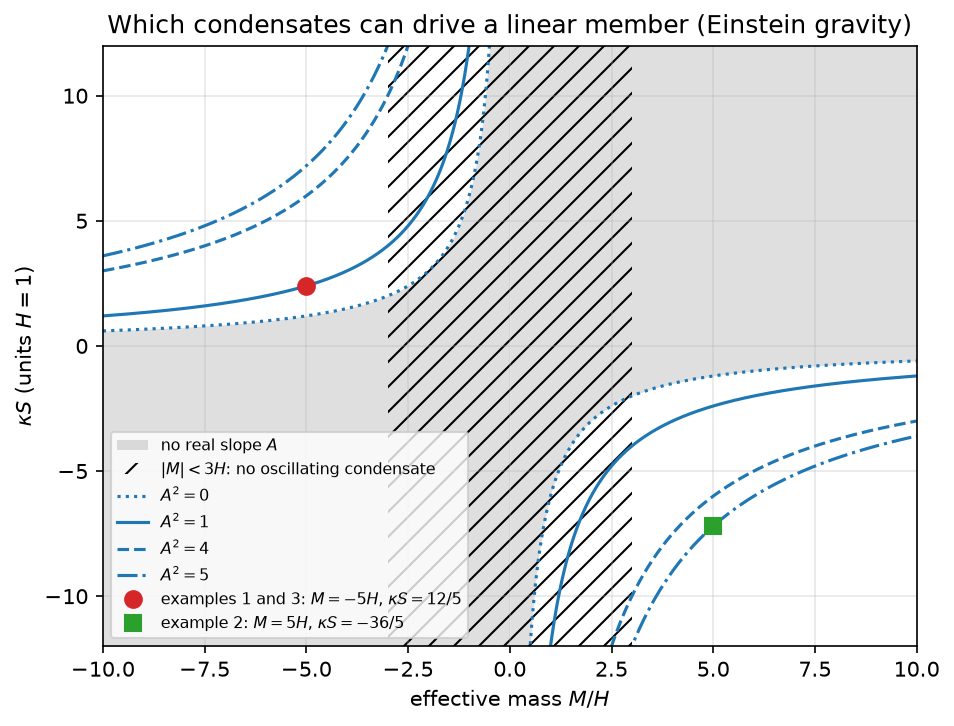

Figure 12d.3 saved as Revision/textbook/figures/12d_3_allowed_sources.png


In [14]:
m_left = np.linspace(-10.0, -0.01, 1000)  # M/H < 0
m_right = np.linspace(0.01, 10.0, 1000)  # M/H > 0
fig, ax = plt.subplots(figsize=(7.0, 5.2))
# grey: kappa M S > -6, where A^2 = -kappa M S/6 - 1 would be negative
ax.fill_between(m_left, -12.0, np.minimum(-6.0 / m_left, 12.0), color="grey",
                alpha=0.25, linewidth=0.0)
ax.fill_between(m_right, np.maximum(-6.0 / m_right, -12.0), 12.0, color="grey",
                alpha=0.25, linewidth=0.0, label="no real slope $A$")
ax.axvspan(-3.0, 3.0, facecolor="none", edgecolor="black", hatch="//",
           linewidth=0.0, label="$|M| < 3H$: no oscillating condensate")
for slope_squared, style in ((0, ":"), (1, "-"), (4, "--"), (5, "-.")):
    level = 6.0 * (slope_squared + 1)
    label = f"$A^2 = {slope_squared}$"
    ax.plot(m_left, -level / m_left, style, color="tab:blue", label=label)
    ax.plot(m_right, -level / m_right, style, color="tab:blue")
ax.plot([-5], [12 / 5], "o", color="tab:red", markersize=8,
        label="examples 1 and 3: $M = -5H$, $\\kappa S = 12/5$")
ax.plot([5], [-36 / 5], "s", color="tab:green", markersize=8,
        label="example 2: $M = 5H$, $\\kappa S = -36/5$")
ax.set_xlim(-10, 10)
ax.set_ylim(-12, 12)
ax.set_xlabel("effective mass $M/H$")
ax.set_ylabel("$\\kappa S$ (units $H = 1$)")
ax.set_title("Which condensates can drive a linear member (Einstein gravity)")
ax.legend(fontsize=7.5, loc="lower left")
save_figure(fig, "allowed_sources",
            "The plane of the effective mass $M/H$ (horizontal) and $\\kappa S$, the "
            "gravitational coupling times the density of the condensate (vertical, "
            "units $H = 1$). In Einstein gravity a homogeneous condensate is the "
            "source of the linear member $a_4 = AHx_4$ only if "
            "$\\kappa MS = -6(A^2 + 1)H^2$: on the blue hyperbolas, drawn for "
            "$A^2 = 0, 1, 4, 5$ (each serves $+A$ and $-A$); in the grey region no "
            "real slope exists. Inside the hatched band $|M| < 3H$ a condensate does "
            "not oscillate. The red circle (examples 1 and 3, $A = 1$) and the green "
            "square (example 2, $A^2 = 5$) are the exact solutions of this notebook; "
            "$S$ and $M$ have opposite signs, as the condition requires.")

## 12. Three exact solutions of the coupled equations

With $H = \kappa = 1$ and the slopes $A = 1$ (the author's deflating history) and
$A = \sqrt5$:

| example | $A$ | $\Lambda$ | $M$ | $S$ | $m$ | $\lambda$ | $\rho$ | $p$ |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | $1$ | $0$ | $-5$ | $12/5$ | $-15$ | $25/6$ | $-24$ | $12$ |
| 2 | $\sqrt5$ | $0$ | $5$ | $-36/5$ | $5$ | $0$ | $-36$ | $0$ |
| 3 | $1$ | $-30$ | $-5$ | $12/5$ | $10$ | $-25/4$ | $6$ | $-18$ |

(from $S = -6(A^2 + 1)/M$, $m = -(36 + 2\Lambda)/S$, $\lambda = (M - m)/S$,
$\rho = mS + \lambda S^2/2$, $p = \lambda S^2/2$). Examples 1 and 2 are the two
worked examples of Notebook 12b (there $S$ and $A^2$ were found from $m$,
$\lambda$ and $\Lambda$); example 3 has a positive energy density. For each, the
next cell computes the parameter $t$ of the family from $S(t)$, builds
$\Phi_0(t)$ (at $M = +5$ for example 2), and checks EXACTLY:

1. the 16 components of the field equation $\gamma^\mu D_\mu\Phi = (m +
   \lambda S)\Phi$ for $\Phi = e^{-iwx_4}\Phi_0$, with the full $\sum_\mu
   \gamma^\mu\Omega_\mu$ of section 7, an arbitrary $a_4(x_4)$ and every $z$;
2. all 64 components $G^\mu{}_\nu + \Lambda\delta^\mu_\nu - \kappa T^\mu{}_\nu = 0$
   of the Einstein equations for the linear member with this $A$, at every
   $x_4$ and $z$ ($T$ from section 10, $G$ from the record);
3. the same 64 components with $-A$: the equations contain $A$ only as $A^2$.

In [15]:
EXAMPLES = [  # name, A, Lambda, M (with H = kappa = 1)
    ("example 1", sp.Integer(1), sp.Integer(0), -5),
    ("example 2", sp.sqrt(5), sp.Integer(0), 5),
    ("example 3", sp.Integer(1), sp.Integer(-30), -5),
]
UNITS = {H: 1, kappa: 1}
solutions = {}  # name -> the numbers of the solution
for name, slope, cosmological, M_example in EXAMPLES:
    S_value = sp.nsimplify(S_needed.subs(UNITS).subs({M_value: M_example,
                                                    A: slope}))
    m_value = m_needed.subs(UNITS).subs({S_sym: S_value, Lam: cosmological})
    lam_value = (M_example - m_value) / S_value
    spaces_e, v1_e, v2_e, c_e, w_e, A_e = witness_parts(M_example, 1)
    S_of_t = bilinear((v1_e + t * c_e * v2_e).applyfunc(sp.expand), I16)
    t_value = sp.solve(S_of_t - S_value, t)[0]
    phi0 = (v1_e + t_value * c_e * v2_e).applyfunc(sp.expand)
    phi = phi0 * sp.exp(-sp.I * w_e * x4)  # the condensate Phi(x4)
    # 1. the field equation, with the full spin-connection sum of section 7:
    residual = (gamma[3] * sp.diff(phi, x4) + gravity_term.subs(UNIT_H) * phi
                - (m_value + lam_value * S_value) * phi).applyfunc(sp.simplify)
    field_ok = residual == sp.zeros(16, 1) and bilinear(phi0, I16) == S_value
    # 2. the Einstein equations, all 64 components, for +A and for -A:
    K_e = K_sym if M_example == -5 else None
    if K_e is None:  # example 2 has its own condensate matrix A (M = +5)
        K_raw = [[(phi0.H * ((C * gamma_1[mu] * ((A_e if nu == 3 else Z16)
                                                 + Omega_1[nu])
                              - ((A_e.T * C if nu == 3 else Z16) - C * Omega_1[nu])
                              * gamma_1[mu]) / 2) * phi0)[0]
                  for nu in range(8)] for mu in range(8)]
        K_e = [[clean((K_raw[mu][nu] + (g_1[nu] / g_1[mu]) * K_raw[nu][mu]) / 2)
                for nu in range(8)] for mu in range(8)]
    else:
        K_e = [[entry.subs(t, t_value) for entry in row] for row in K_e]
    T_e = source_tensor(K_e, S_value, m_value, lam_value)
    einstein_ok = {}
    for sign in (1, -1):
        G_diag = [G_space] * 3 + [G_time] + [G_extra] * 3 + [G_hidden]
        values = {A: sign * slope, H: 1}
        einstein_ok[sign] = all(
            sp.simplify((G_diag[mu].subs(values) + cosmological if mu == nu else 0)
                        - T_e[mu][nu]) == 0
            for mu in range(8) for nu in range(8))
    rho_e, p_e = -T_e[3][3], T_e[0][0]
    solutions[name] = {"A": slope, "Lambda": cosmological, "M": M_example,
                       "S": S_value, "m": m_value, "lambda": lam_value, "t": t_value,
                       "rho": rho_e, "p": p_e, "phi0": phi0, "w": w_e, "T": T_e}
    say(f"{name}: A = {slope}, Lambda = {cosmological}, M = {M_example}, "
        f"S = {S_value}, t = {t_value}, m = {m_value}, lambda = {lam_value}, "
        f"rho = {rho_e}, p = {p_e}")
    check(field_ok, f"{name}: the 16 components of the field equation hold exactly")
    check(einstein_ok[1], f"{name}: all 64 Einstein components hold exactly")
    check(einstein_ok[-1], f"{name}: they hold as well with -A (A enters as A^2)")

example 1: A = 1, Lambda = 0, M = -5, S = 12/5, t = 15/512, m = -15, lambda = 25/6, rho =
    -24, p = 12
PASS example 1: the 16 components of the field equation hold exactly
PASS example 1: all 64 Einstein components hold exactly
PASS example 1: they hold as well with -A (A enters as A^2)
example 2: A = sqrt(5), Lambda = 0, M = 5, S = -36/5, t = -45/512, m = 5, lambda = 0, rho
    = -36, p = 0
PASS example 2: the 16 components of the field equation hold exactly
PASS example 2: all 64 Einstein components hold exactly
PASS example 2: they hold as well with -A (A enters as A^2)
example 3: A = 1, Lambda = -30, M = -5, S = 12/5, t = 15/512, m = 10, lambda = -25/4, rho
    = 6, p = -18
PASS example 3: the 16 components of the field equation hold exactly
PASS example 3: all 64 Einstein components hold exactly
PASS example 3: they hold as well with -A (A enters as A^2)


The next cell compares the numbers with the table above and with Notebook 12b's
formula $A^2 = 5 + \Lambda/3 - \lambda S^2/6$ (Einstein gravity, $H = \kappa = 1$),
and reports the equation of state $w = p/\rho$ of each source.

In [16]:
table = {"example 1": (sp.Rational(12, 5), -15, sp.Rational(25, 6), -24, 12),
         "example 2": (sp.Rational(-36, 5), 5, 0, -36, 0),
         "example 3": (sp.Rational(12, 5), 10, sp.Rational(-25, 4), 6, -18)}
for name, (S_v, m_v, lam_v, rho_v, p_v) in table.items():
    sol = solutions[name]
    same = (sol["S"] == S_v and sol["m"] == m_v and sol["lambda"] == lam_v
            and sol["rho"] == rho_v and sol["p"] == p_v)
    formula = 5 + sol["Lambda"] / 3 - sol["lambda"] * sol["S"] ** 2 / 6
    check(same and sp.simplify(formula - sol["A"] ** 2) == 0,
          f"{name}: the numbers of the table and A^2 = 5 + Lambda/3 - lambda S^2/6")
    report(f"{name}: w = p/rho", sol["p"] / sol["rho"])

PASS example 1: the numbers of the table and A^2 = 5 + Lambda/3 - lambda S^2/6
RESULT example 1: w = p/rho = -1/2
PASS example 2: the numbers of the table and A^2 = 5 + Lambda/3 - lambda S^2/6
RESULT example 2: w = p/rho = 0
PASS example 3: the numbers of the table and A^2 = 5 + Lambda/3 - lambda S^2/6
RESULT example 3: w = p/rho = -3


The next cell draws, for example 3, the left-hand side $G^\mu{}_\nu +
\Lambda\delta^\mu_\nu$ and the right-hand side $\kappa T^\mu{}_\nu$ of the Einstein
equations as two 8 by 8 tables, and their difference (zero everywhere).

PASS example 3: the two 8 by 8 tables are equal entry by entry


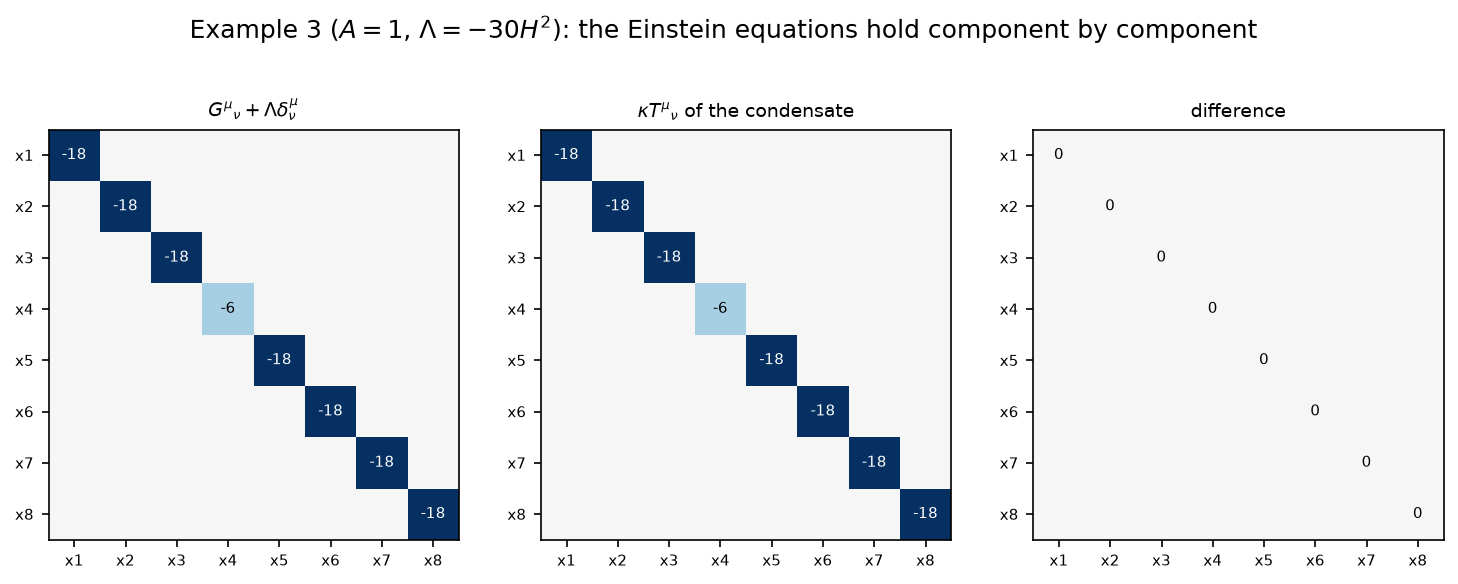

Figure 12d.4 saved as Revision/textbook/figures/12d_4_tensor_equality.png


In [17]:
sol = solutions["example 3"]
G_diag = [G_space] * 3 + [G_time] + [G_extra] * 3 + [G_hidden]
left_side = np.array([[float(G_diag[mu].subs({A: 1, H: 1}) + sol["Lambda"])
                       if mu == nu else 0.0 for nu in range(8)] for mu in range(8)])
right_side = np.array([[float(sol["T"][mu][nu]) for nu in range(8)]
                       for mu in range(8)])
check(np.max(np.abs(left_side - right_side)) == 0.0,
      "example 3: the two 8 by 8 tables are equal entry by entry")
fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.4))
scale = np.abs(right_side).max()
panels = ((left_side, "$G^\\mu{}_\\nu + \\Lambda\\delta^\\mu_\\nu$"),
          (right_side, "$\\kappa T^\\mu{}_\\nu$ of the condensate"),
          (left_side - right_side, "difference"))
for ax, (values, title) in zip(axes, panels):
    ax.imshow(values, cmap="RdBu_r", vmin=-scale, vmax=scale)
    for mu in range(8):
        value = values[mu, mu]
        ink = "white" if abs(value) > 0.6 * scale else "black"  # readable on dark
        ax.text(mu, mu, f"{value:.0f}", ha="center", va="center", fontsize=7,
                color=ink)
    ax.set_xticks(range(8))
    ax.set_xticklabels(NAMES, fontsize=7)
    ax.set_yticks(range(8))
    ax.set_yticklabels(NAMES, fontsize=7)
    ax.grid(False)
    ax.set_title(title, fontsize=9)
fig.suptitle("Example 3 ($A = 1$, $\\Lambda = -30H^2$): the Einstein equations hold "
             "component by component")
save_figure(fig, "tensor_equality",
            "Example 3 (the deflating member $A = 1$, $\\Lambda = -30H^2$, units "
            "$H = \\kappa = 1$): left, the left-hand side $G^\\mu{}_\\nu + "
            "\\Lambda\\delta^\\mu_\\nu$ of the Einstein equations; middle, the "
            "right-hand side $\\kappa T^\\mu{}_\\nu$ computed from the condensate "
            "$\\Phi = e^{-4ix_4}\\Phi_0$; right, their difference. Rows $\\mu$ and "
            "columns $\\nu$ run over $x_1$ to $x_8$; the colour is the value (red "
            "positive, blue negative, white zero) and the numbers are the diagonal "
            "entries: $-6$ (minus the energy density, $x_4$) and $-18$ (the "
            "pressure, every other direction). All 64 entries agree exactly; every "
            "mixed entry is zero.")

## 13. The solution in time

The next cell draws example 1 as functions of the time $x_4$: on the left the real
parts of three components of $\Phi(x_4) = e^{-4ix_4}\Phi_0$ (they oscillate with
the period $2\pi/4$) and the density $S = 12/5$, which stays constant; on the
right, on a logarithmic axis, the scale factor $e^{a_4} = e^{x_4}$ of 3-space and
$e^{-a_4} = e^{-x_4}$ of the extra times, which deflate exponentially, together
with those of example 2 ($a_4 = \sqrt5\,x_4$).

PASS example 1: S(x4) = 12/5 at every time (numerically)


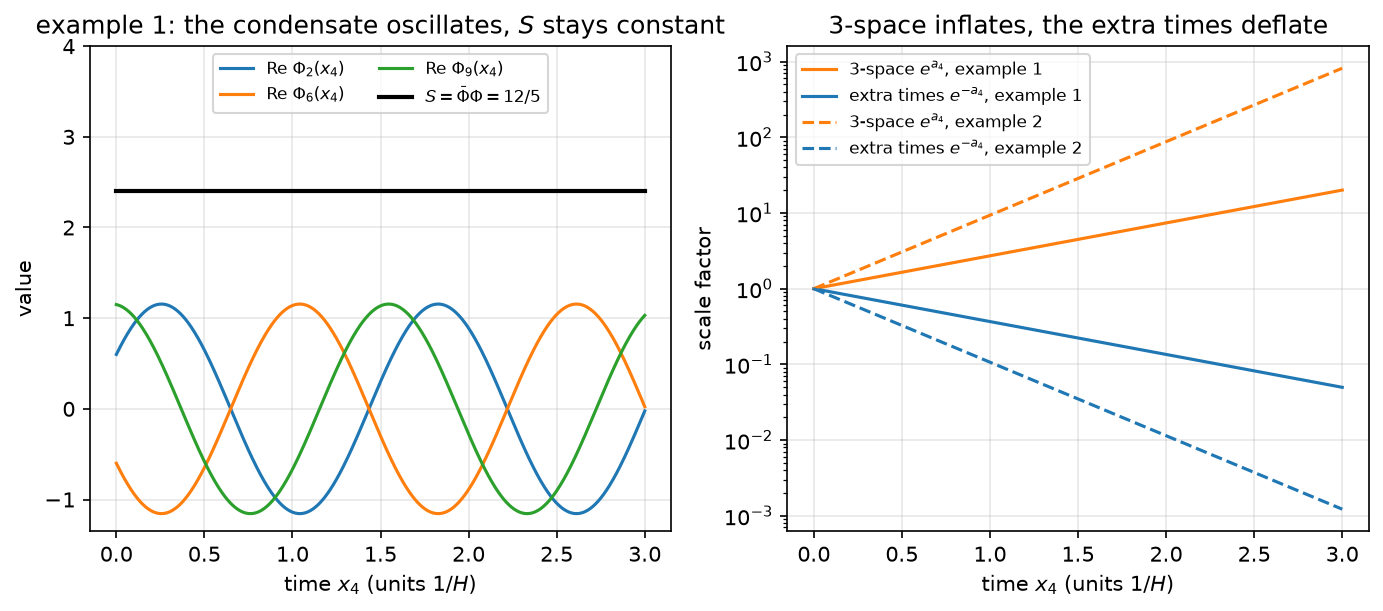

Figure 12d.5 saved as Revision/textbook/figures/12d_5_solution_in_time.png


In [18]:
sol = solutions["example 1"]
phi_numbers = np.array([complex(entry) for entry in sol["phi0"]])
biggest = np.argsort(-np.abs(phi_numbers), kind="stable")[:3]  # three components
times = np.linspace(0.0, 3.0, 601)  # x4 in units 1/H
density = []
for x_value in times:  # S from the numbers, at every time (it must stay 12/5)
    phi_x = phi_numbers * np.exp(-4j * x_value)
    density.append((phi_x.conj() @ np.array(C.tolist(), dtype=float) @ phi_x).real)
density = np.array(density)
check(np.max(np.abs(density - 12 / 5)) < 1e-12,
      "example 1: S(x4) = 12/5 at every time (numerically)")
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.2))
for index in sorted(biggest):
    left.plot(times, (phi_numbers[index] * np.exp(-4j * times)).real,
              label=f"Re $\\Phi_{{{index + 1}}}(x_4)$")
left.plot(times, density, color="black", linewidth=2.0,
          label="$S = \\bar\\Phi\\Phi = 12/5$")
left.set_ylim(-1.35, 4.0)  # room for the legend above the curves
left.set_xlabel("time $x_4$ (units $1/H$)")
left.set_ylabel("value")
left.set_title("example 1: the condensate oscillates, $S$ stays constant")
left.legend(fontsize=8, loc="upper center", ncol=2)
for name, style in (("example 1", "-"), ("example 2", "--")):
    slope = float(solutions[name]["A"])
    right.semilogy(times, np.exp(slope * times), style, color="tab:orange",
                   label=f"3-space $e^{{a_4}}$, {name}")
    right.semilogy(times, np.exp(-slope * times), style, color="tab:blue",
                   label=f"extra times $e^{{-a_4}}$, {name}")
right.set_xlabel("time $x_4$ (units $1/H$)")
right.set_ylabel("scale factor")
right.set_title("3-space inflates, the extra times deflate")
right.legend(fontsize=8)
save_figure(fig, "solution_in_time",
            "The exact solution of example 1 as a function of the time $x_4$ (units "
            "$1/H$). Left: the real parts of the three largest components of the "
            "condensate $\\Phi(x_4) = e^{-4ix_4}\\Phi_0$, which oscillate with the "
            "period $2\\pi/4 \\approx 1.57$, and its density $S = \\bar\\Phi\\Phi = "
            "12/5$ (black), constant at every time. Right, on a logarithmic axis: "
            "the scale factor $e^{a_4}$ of 3-space (orange) and $e^{-a_4}$ of the "
            "three extra times (blue), for example 1 ($a_4 = Hx_4$, solid) and "
            "example 2 ($a_4 = \\sqrt5\\,Hx_4$, dashed): the extra times deflate "
            "exponentially while 3-space inflates, driven by the condensate.")

## 14. The whole family for the deflating member $A = 1$

For $A = 1$, $M = -5$ and $S = 12/5$ (the condensate of examples 1 and 3) every
cosmological constant gives a solution: $m = -(36 + 2\Lambda)/S$,
$\lambda = (M - m)/S$, $\kappa\rho = -24 - \Lambda$, $\kappa p = 12 + \Lambda$. The
next cell checks this family against the exact solutions and draws $m$, $\lambda$,
$\kappa\rho$ and $\kappa p$ as functions of $\Lambda$. The energy density is
positive only for $\Lambda < -24H^2$, and then $p < -\rho$: $w < -1$, because
$\kappa(\rho + p) = \kappa MS = -12H^2$ for every $\Lambda$ (the violation of the
null energy condition that Notebook 12a proved for every source of this metric).

PASS A = 1 family: kappa rho = -24 - Lambda, kappa p = 12 + Lambda


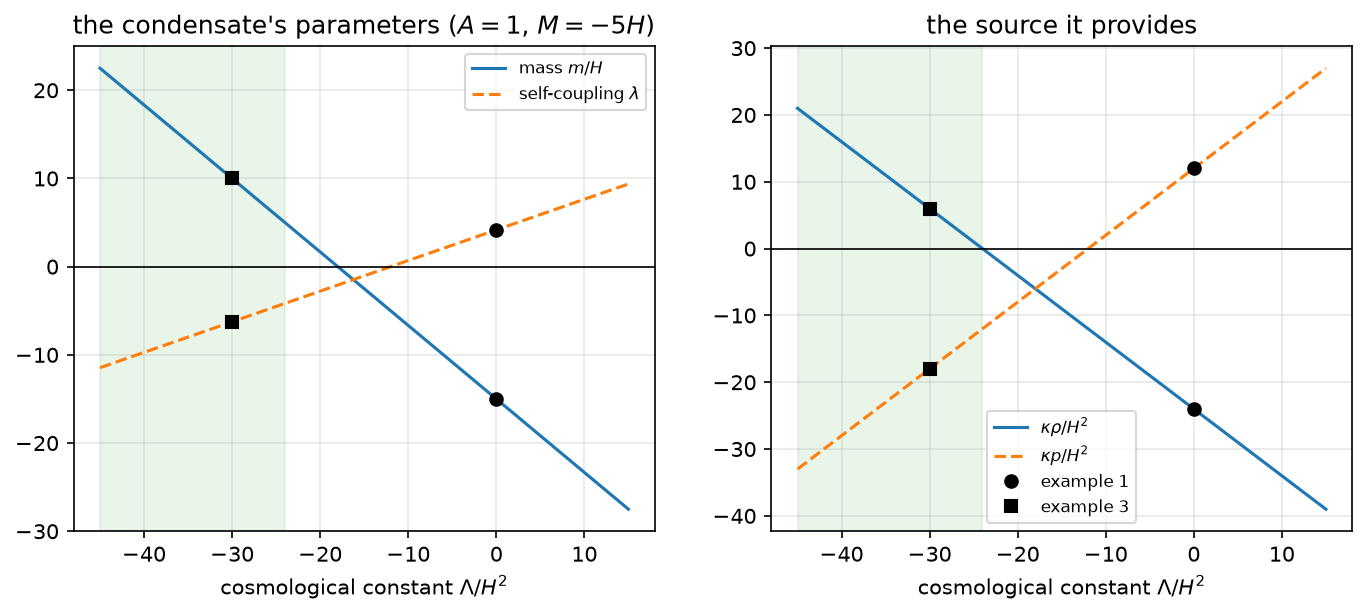

Figure 12d.6 saved as Revision/textbook/figures/12d_6_family_in_lambda.png


In [19]:
lam_axis = sp.symbols("Lambda_axis", real=True)
S_one = sp.Rational(12, 5)
m_family = -(36 + 2 * lam_axis) / S_one
lam_family = (-5 - m_family) / S_one
rho_family_line = m_family * S_one + lam_family * S_one ** 2 / 2
p_family_line = lam_family * S_one ** 2 / 2
check(sp.expand(rho_family_line - (-24 - lam_axis)) == 0
      and sp.expand(p_family_line - (12 + lam_axis)) == 0
      and m_family.subs(lam_axis, 0) == solutions["example 1"]["m"]
      and m_family.subs(lam_axis, -30) == solutions["example 3"]["m"],
      "A = 1 family: kappa rho = -24 - Lambda, kappa p = 12 + Lambda")
axis = np.linspace(-45.0, 15.0, 301)
functions = [sp.lambdify(lam_axis, f, "numpy") for f in
             (m_family, lam_family, rho_family_line, p_family_line)]
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.2))
left.plot(axis, functions[0](axis), label="mass $m/H$")
left.plot(axis, functions[1](axis), "--", label="self-coupling $\\lambda$")
right.plot(axis, functions[2](axis), label="$\\kappa\\rho/H^2$")
right.plot(axis, functions[3](axis), "--", label="$\\kappa p/H^2$")
for ax in (left, right):
    ax.axvspan(-45.0, -24.0, color="tab:green", alpha=0.1)
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_xlabel("cosmological constant $\\Lambda/H^2$")
for name, marker in (("example 1", "o"), ("example 3", "s")):
    sol = solutions[name]
    x_value = float(sol["Lambda"])
    left.plot([x_value] * 2, [float(sol["m"]), float(sol["lambda"])], marker,
              color="black")
    right.plot([x_value] * 2, [float(sol["rho"]), float(sol["p"])], marker,
               color="black", label=name)
left.set_title("the condensate's parameters ($A = 1$, $M = -5H$)")
right.set_title("the source it provides")
left.legend(fontsize=8)
right.legend(fontsize=8)
save_figure(fig, "family_in_lambda",
            "The family of exact solutions with the deflating member $a_4 = Hx_4$ "
            "and the condensate of examples 1 and 3 ($M = -5H$, $\\kappa S = 12/5$), "
            "as functions of the cosmological constant $\\Lambda/H^2$ (units "
            "$H = \\kappa = 1$). Left: the mass $m = -(36 + 2\\Lambda)/S$ and the "
            "self-coupling $\\lambda = (M - m)/S$ the condensate must have. Right: "
            "its energy density $\\kappa\\rho = -24 - \\Lambda$ and pressure "
            "$\\kappa p = 12 + \\Lambda$. Black circles: example 1 ($\\Lambda = 0$); "
            "black squares: example 3 ($\\Lambda = -30$). In the green region "
            "$\\Lambda < -24H^2$ the energy density is positive, and there "
            "$p < -\\rho$ ($w < -1$), since $\\kappa(\\rho + p) = -12H^2$ for every "
            "$\\Lambda$.")

## 15. What this shows, and what it does not

- **PROVED here (exact):** for each of the three examples the author's metric with
  the linear member ($a_4 = Hx_4$ for examples 1 and 3: the extra times deflate as
  $e^{-Hx_4}$; $a_4 = \sqrt5\,Hx_4$ for example 2) and the condensate
  $\Phi = e^{-iwx_4}\Phi_0$ solve the field equation of dirac16complex00 (16
  components) and the Einstein equations (64 components) at every time and every
  value of the hidden coordinate. So the coupled equations of the theory have exact
  solutions in which a field of the theory drives the exponential deflation of the
  extra times. This answers, for these examples, the combination that the Revision
  record leaves open; it is a computation of this notebook, not a Revision record.
- **ASSUMED:** Einstein gravity ($\alpha_2 = \alpha_3 = 0$); the record's sign
  convention $\sigma_T = +1$ of the energy-momentum tensor (with the opposite sign
  every $\rho$ and $p$ changes sign and the conditions change accordingly); the
  classical commuting field dirac16complex00, not the quantised dirac16complex; the
  chosen values of $\Lambda$, $m$, $\lambda$.
- **The sign of $A$ is not selected:** the same condensate solves the equations
  with $-A$ (inflating extra times); the deflation is the author's choice of sign.
- **Energy:** with $\Lambda = 0$ the energy density is negative (examples 1 and 2);
  a positive energy density needs $\Lambda < -(21 + 3A^2)H^2$ and then has
  $w < -1$ (example 3: $w = -3$).
- **Not shown:** whether such a condensate is stable, how it could arise, any
  statement about the quantised field, and nothing about the creation of
  universes.

## 16. The last check

The last cell checks that the six figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [20]:
figure_names = ["condensate_frequency", "three_gamma_bilinears", "allowed_sources",
                "tensor_equality", "solution_in_time", "family_in_lambda"]
paths = [output_file(f"{FIGURE_FOLDER}/12d_{k}_{name}.png")
         for k, name in enumerate(figure_names, 1)]
check(all(path.is_file() for path in paths), "all six figure files exist")
all_checks_passed()

PASS all six figure files exist
ALL 40 CHECKS PASSED (notebook 12d)


## 17. What this notebook showed

- With the author's gammas, the spin connection of the author's metric gives
  $\sum_\mu\gamma^\mu\Omega_\mu = 3H\gamma^{(x_8)}$, and a homogeneous condensate
  obeys $\Phi' = \mathcal{A}\Phi$ with $\mathcal{A}^2 = -(M^2 - 9H^2)$: it
  oscillates with $w = \sqrt{M^2 - 9H^2}$ and keeps $S$ constant, whatever $a_4$
  does (PROVED, reproducing the Revision record).
- The family $\Phi_0(t) = v_1 + t\,c\,v_2$ has all 15 three-gamma bilinears zero for
  every real $t$ and the density $S(t) = 2t|v_1^\dagger Cv_2|^2$ of either sign
  (PROVED); its energy-momentum tensor is diagonal, $\rho = mS + \lambda S^2/2$,
  $p_3 = p_t = p_8 = \lambda S^2/2$, for every $a_4$ (PROVED).
- Three exact solutions of the coupled Einstein and dirac16complex00 equations,
  two with the extra times deflating as $e^{-Hx_4}$: all 16 + 64 components hold
  exactly (PROVED for the stated numbers, under the ASSUMED convention
  $\sigma_T = +1$ and Einstein gravity).
- The equations do not select the sign of $A$; a positive energy density requires
  $\Lambda < -(21 + 3A^2)H^2$ and $w < -1$ (PROVED).